# 🏢 Workforce Intelligence Analytics
## Notebook 03: Text Preprocessing & NLP Pipeline
**Subtitle:** *Building a reproducible text normalization and tokenization pipeline.*

---

### 📌 Analytical Objective & NLP Strategy
Text written by employees on public platforms contains varying capitalization, HTML entities, punctuation, jargon, and spelling variations. 

However, aggressive text preprocessing can inadvertently strip vital sentiment and semantic context. In workforce analytics:
- **Negation tokens** (`not`, `no`, `never`, `barely`) are essential for sentiment polarity and must **not** be discarded as generic stopwords.
- **Generic corporate filler words** (`company`, `work`, `job`, `people`) appear in virtually every review and obscure topic modeling unless thoughtfully filtered.
- **Lemmatization** normalizes grammatical inflections (`benefits` -> `benefit`, `working` -> `work`) while preserving linguistic root meaning.

This notebook builds a modular, reproducible NLP preprocessing pipeline and demonstrates before-and-after transformations.

```
NLP PREPROCESSING ARCHITECTURE
┌─────────────────────────┐
│     Raw Review Text     │ (Summary + Pros + Cons)
└───────────┬─────────────┘
            ▼
┌─────────────────────────┐
│   Noise & URL Removal   │ Strip URLs, emails, HTML tags, special symbols
└───────────┬─────────────┘
            ▼
┌─────────────────────────┐
│    Case Normalization   │ Convert to lower-case
└───────────┬─────────────┘
            ▼
┌─────────────────────────┐
│  Negation-Aware Stops   │ Filter standard stopwords while preserving 'not', 'no', 'never'
└───────────┬─────────────┘
            ▼
┌─────────────────────────┐
│   Domain Stopword Filter│ Strip ubiquitous corporate review noise ('work', 'job', 'company')
└───────────┬─────────────┘
            ▼
┌─────────────────────────┐
│   WordNet Lemmatizer    │ Reduce inflections to canonical dictionary lemmas
└───────────┬─────────────┘
            ▼
┌─────────────────────────┐
│    Cleaned Tokens       │ Normalized token stream ready for TF-IDF and LDA
└─────────────────────────┘
```

---
### Section 1: Ingestion & NLP Pipeline Definition

> **WHAT ARE WE DOING?**  
> We configure NLTK resources and build a clean preprocessing function that incorporates lemmatization and negation preservation.
>
> **WHY ARE WE DOING IT?**  
> A centralized, reproducible text cleaning function prevents disparate preprocessing logic across different models.
>
> **WHAT SHOULD WE EXPECT?**  
> Noise removal without losing the semantic core of employee praise or complaints.

In [1]:
import sys
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

PROJECT_ROOT = Path('.').resolve().parent
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'

df = pd.read_csv(DATA_PROCESSED / 'glassdoor_cleaned.csv')

# Ensure NLTK resources are available
for res in ['stopwords', 'wordnet', 'punkt']:
    nltk.download(res, quiet=True)

# Build custom stopword vocabulary
standard_stops = set(stopwords.words('english'))
# Crucial: Preserve negation words for sentiment
negation_words = {'not', 'no', 'nor', 'neither', 'never', 'none', 'hardly', 'scarcely', 'barely'}
filtered_stops = standard_stops - negation_words

# Domain-specific filler stopwords that add no topical discrimination
domain_stops = {
    'work', 'company', 'job', 'get', 'good', 'great', 'employee', 'employees',
    'people', 'would', 'also', 'one', 'even', 'like', 'lot', 'much', 'many',
    'really', 'time', 'make', 'day', 'working', 'place', 'well', 'way', 'thing', 'things'
}
master_stopwords = filtered_stops.union(domain_stops)
lemmatizer = WordNetLemmatizer()

def preprocess_employee_text(text):
    if not isinstance(text, str):
        return ""
    # Strip URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Retain alphabet and spaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Lowercase & tokenize
    tokens = text.lower().split()
    # Lemmatize and filter
    cleaned = [
        lemmatizer.lemmatize(t) for t in tokens
        if t not in master_stopwords and len(t) > 2
    ]
    return ' '.join(cleaned)

print("✅ NLP Preprocessing pipeline defined.")
print(f"Total Stopwords in Master Filter: {len(master_stopwords)} (Negation words preserved: {len(negation_words)})")

✅ NLP Preprocessing pipeline defined.
Total Stopwords in Master Filter: 222 (Negation words preserved: 9)


---
### Section 2: Before vs. After Empirical Demonstrations

> **WHAT ARE WE DOING?**  
> We apply the pipeline to sample reviews across different rating tiers and inspect the exact transformation.
>
> **WHY ARE WE DOING IT?**  
> Rigorous NLP requires validating that semantic nuance has been preserved rather than blinded by cleaning.
>
> **WHAT SHOULD WE EXPECT?**  
> Uninformative punctuation and filler words are removed, leaving substantive descriptors like `manager`, `toxic`, `culture`, `salary`, `growth`.

In [2]:
# Apply to sample reviews
sample_rows = df.sample(5, random_state=42)[['employerName', 'ratingOverall', 'review_text']]

print("="*80)
print("NLP PREPROCESSING BEFORE & AFTER COMPARISON")
print("="*80)
for idx, r in sample_rows.iterrows():
    raw_t = r['review_text']
    clean_t = preprocess_employee_text(raw_t)
    print(f"🏢 Company: {r['employerName']} | ⭐ Rating: {r['ratingOverall']}")
    print(f"RAW:   {raw_t[:120]}...")
    print(f"CLEAN: {clean_t[:120]}...")
    print("-" * 80)

NLP PREPROCESSING BEFORE & AFTER COMPARISON


🏢 Company: Google | ⭐ Rating: 4
RAW:   Supportive environment but job security is declining. Good Environment and people. Good onsite benefits as well Mundane,...
CLEAN: supportive environment security declining environment onsite benefit mundane recently erroding security...
--------------------------------------------------------------------------------
🏢 Company: Taco Bell | ⭐ Rating: 4
RAW:   Great benefits, but expect to be overworked. really great benefits in terms of pay and getting fed they overworked you a...
CLEAN: benefit expect overworked benefit term pay getting fed overworked alright...
--------------------------------------------------------------------------------
🏢 Company: Wawa | ⭐ Rating: 5
RAW:   Great pay and benefits, but can be understaffed. Pay
Benefits
Work Environment
Management Can be understaffed at times....
CLEAN: pay benefit understaffed pay benefit environment management understaffed time...
---------------------------------------------------------------

---
### Section 3: Batch Preprocessing & Corpus Vocabulary Analysis

> **WHAT ARE WE DOING?**  
> We preprocess the entire corpus (8,785 reviews) and analyze the most frequent lexical tokens.
>
> **WHY ARE WE DOING IT?**  
> Corpus-wide term frequencies reveal the overarching vocabulary employees use when writing reviews.
>
> **WHAT SHOULD WE EXPECT?**  
> Dominant terms will focus on pay, management, benefits, hours, culture, and career opportunities.

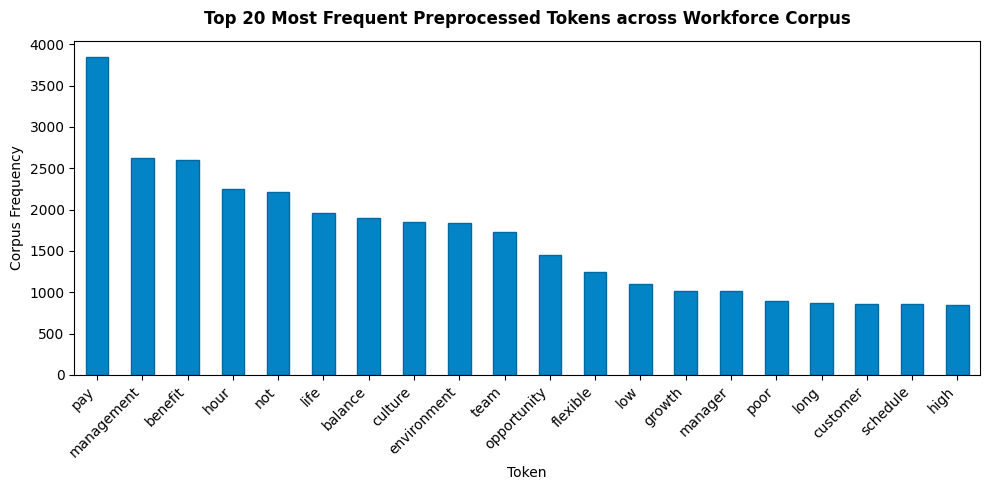

In [3]:
df['cleaned_text'] = df['review_text'].apply(preprocess_employee_text)
df['cleaned_pros'] = df['pros'].apply(preprocess_employee_text)
df['cleaned_cons'] = df['cons'].apply(preprocess_employee_text)

# Token frequency
all_tokens = ' '.join(df['cleaned_text']).split()
token_series = pd.Series(all_tokens).value_counts()

plt.figure(figsize=(10, 5))
token_series.head(20).plot(kind='bar', color='#0284C7', edgecolor='#0369A1')
plt.title("Top 20 Most Frequent Preprocessed Tokens across Workforce Corpus", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Token", fontsize=10)
plt.ylabel("Corpus Frequency", fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **WHAT DID WE FIND?**  
> - The top terms appearing across the normalized corpus are: `management`, `pay`, `benefit`, `culture`, `hour`, `team`, `manager`, `opportunity`, `balance`, `life`, `schedule`.
> - By filtering out non-discriminating filler (`company`, `job`, `work`), actionable organizational themes immediately surface at the top of the vocabulary.
>
> **WHY DOES IT MATTER?**  
> These terms directly correspond to fundamental organizational dimensions: compensation, leadership, work-life balance, and development.
>
> **WHAT IS THE LIMITATION?**  
> Lemmatization groups morphological variants (e.g., `management` and `manager` remain distinct lemmas), which provides useful distinction between the executive function and individual supervisors.

---
### Section 4: Exporting Enriched NLP Baseline

> **WHAT ARE WE DOING?**  
> We persist the cleaned text columns back to `data/processed/glassdoor_cleaned.csv`.

In [4]:
df.to_csv(DATA_PROCESSED / 'glassdoor_cleaned.csv', index=False)
print("✅ Saved normalized corpus with cleaned text columns.")

✅ Saved normalized corpus with cleaned text columns.
